# 2 · The 10 km target grid

Every dataset is aligned onto a single [`TargetGrid`](../api/grid.md#data4simplace.grid.TargetGrid), and every
cell carries one deterministic `SimplaceID` that is shared across the
weather, soil and management outputs. This notebook builds a grid, reads
its cell table, and demonstrates regridding. No external data required.

## Build a grid from a `GridConfig`

In [ ]:
from data4simplace.config import GridConfig
from data4simplace.grid import TargetGrid

grid_cfg = GridConfig(
    resolution_deg=0.1,
    min_lon=11.2, max_lon=14.8,
    min_lat=51.3, max_lat=53.6,
)
grid = TargetGrid.from_config(grid_cfg)
print('grid shape (n_lat, n_lon):', grid.shape)
print('n cells:', grid.shape[0] * grid.shape[1])

## The cell table and `SimplaceID`

`SimplaceID` is assigned in row-major order (north→south, west→east) and
is stable for a given bounding box + resolution.

In [ ]:
cells = grid.cell_table()
cells.head()

In [ ]:
print('columns:', list(cells.columns))
print('SimplaceID range:', cells.SimplaceID.min(), '->', cells.SimplaceID.max())

## Visualise the grid cells coloured by `SimplaceID`

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(cells.lon, cells.lat, c=cells.SimplaceID, s=14, cmap='viridis')
ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
ax.set_title('Target grid cell centres (colour = SimplaceID)')
fig.colorbar(sc, ax=ax, label='SimplaceID')
plt.tight_layout()

## Regrid a finer field onto the target grid

`TargetGrid.regrid` bins a finer source field into each 10 km cell. Here
we synthesise a 0.02° field (5× finer) and aggregate it with the mean.

In [ ]:
import numpy as np
import xarray as xr

fine_res = 0.02
lon = np.arange(11.2 + fine_res / 2, 14.8, fine_res)
lat = np.arange(53.6 - fine_res / 2, 51.3, -fine_res)
field = np.sin(np.deg2rad(lat)[:, None] * 40) + np.cos(np.deg2rad(lon)[None, :] * 40)
da = xr.DataArray(field, dims=('lat', 'lon'), coords={'lat': lat, 'lon': lon}, name='demo')
print('source shape:', da.shape)

coarse = grid.regrid(da, method='mean')
print('regridded shape:', coarse.shape)

In [ ]:
fig, (a, b) = plt.subplots(1, 2, figsize=(10, 4))
da.plot(ax=a); a.set_title('source · 0.02 deg')
coarse.plot(ax=b); b.set_title('regridded · 0.1 deg (mean)')
plt.tight_layout()

## Why the shared `SimplaceID` matters

Because the grid is deterministic, the *same* cell gets the *same*
`SimplaceID` in the weather, soil and management files — that is what lets
SIMPLACE join them back together per point.

In [18]:
FP = "/data01/FDS/muduchuru/Land/SoilGrids/_wcs_cache/soc_0-5cm_mean.tif"

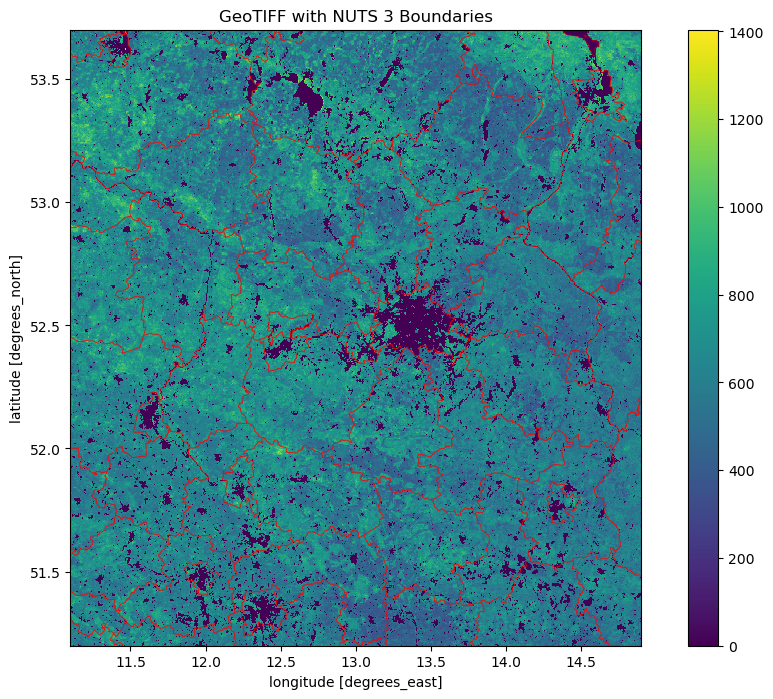

In [21]:
import matplotlib.pyplot as plt
import geopandas as gpd
import rioxarray

# 1. LOAD DATA
da = rioxarray.open_rasterio(FP)
if 'band' in da.dims:
    da = da.squeeze('band')
# da = da.
da = da.rio.reproject("EPSG:4326")
# Fetch NUTS 3
nuts_url = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_01M_2021_4326_LEVL_3.geojson"
nuts3 = gpd.read_file(nuts_url)

# 2. MATCH CRS PROPERLY
# Check if raster has a valid CRS. If missing, assume standard Lat/Lon (EPSG:4326)
raster_crs = da.rio.crs
if raster_crs is None:
    da.rio.write_crs("EPSG:4326", inplace=True)
    raster_crs = "EPSG:4326"

# Reproject NUTS 3 to match the raster
nuts3 = nuts3.to_crs(raster_crs)

# 3. SAFE BOUNDS & CROPPING
left, bottom, right, top = da.rio.bounds()

# Crop NUTS 3 boundaries to raster spatial extent
nuts3_cropped = nuts3.cx[left:right, bottom:top]

# Safety Check: Did the crop return any polygons?
if len(nuts3_cropped) == 0:
    print("⚠️ Warning: No NUTS 3 polygons found within the raster bounds! Plotting uncropped NUTS dataset.")
    nuts3_to_plot = nuts3
else:
    nuts3_to_plot = nuts3_cropped

# 4. PLOT SAFELY
fig, ax = plt.subplots(figsize=(12, 8))

# Draw raster
da.plot(ax=ax, cmap='viridis')#, extent=[left, right, bottom, top])

# Draw vector over raster with aspect='auto' to prevent aspect ratio errors
nuts3_to_plot.plot(
    ax=ax,
    facecolor='none',
    edgecolor='red',
    linewidth=0.5,
    alpha=0.7,
    aspect='auto'  # Explicitly prevents "aspect must be finite" error
)

plt.title("GeoTIFF with NUTS 3 Boundaries")
plt.show()

In [16]:
nuts3

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
0,HR064,3,HR,Krapinsko-zagorska županija,Krapinsko-zagorska županija,4,3,3,Croatia,Croatie,HRV,UN Member State,Zagreb,T,F,F,Kroatien,"MULTIPOLYGON (((15.8824 46.23502, 15.88521 46...."
1,DE933,3,DE,Harburg,Harburg,4,2,3,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland,"MULTIPOLYGON (((9.78358 53.5, 9.78321 53.49212..."
2,DE934,3,DE,Lüchow-Dannenberg,Lüchow-Dannenberg,4,3,3,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland,"MULTIPOLYGON (((10.97163 53.1981, 11.01166 53...."
3,BG314,3,BG,Pleven,Плевен,4,2,3,Bulgaria,Bulgarie,BGR,UN Member State,Sofia,T,F,F,Bulgarien,"MULTIPOLYGON (((24.6949 43.69762, 24.69783 43...."
4,BG331,3,BG,Varna,Варна,4,2,1,Bulgaria,Bulgarie,BGR,UN Member State,Sofia,T,F,F,Bulgarien,"MULTIPOLYGON (((27.42946 43.60027, 27.4397 43...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1509,UKG37,3,UK,Sandwell,Sandwell,4,1,3,United Kingdom,Royaume-Uni,GBR,UN Member State,London,F,F,F,Vereinigtes Königreich,"MULTIPOLYGON (((-1.98893 52.56297, -1.97521 52..."
1510,UKM77,3,UK,Perth & Kinross and Stirling,Perth & Kinross and Stirling,2,2,1,United Kingdom,Royaume-Uni,GBR,UN Member State,London,F,F,F,Vereinigtes Königreich,"MULTIPOLYGON (((-3.90435 56.93136, -3.89569 56..."
1511,NO0B1,3,NO,Jan Mayen,Jan Mayen,3,3,1,Norway,Norvège,NOR,UN Member State,Oslo,F,T,F,Norwegen,"MULTIPOLYGON (((-9.08295 70.86469, -9.07843 70..."
1512,EE009,3,EE,Kesk-Eesti,Kesk-Eesti,4,3,1,Estonia,Estonie,EST,UN Member State,Tallinn,T,F,F,Estland,"MULTIPOLYGON (((25.98343 59.62115, 25.99837 59..."
